## Import Library

In [3]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Baca Dataset

In [4]:
# baca dataset
df = pd.read_csv('/content/Daily Household Transactions.csv')
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [5]:
# baca info kolom dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


## Data Cleaning

In [6]:
# Pengelompokan kategori
# Dictionary 12 Kategori Standar (Fixed Level 1)
standard_mapping = {
    'Small cap fund 1': 'Savings & Investments', 'Small Cap fund 2': 'Savings & Investments',
    'Equity Mutual Fund A': 'Savings & Investments', 'Equity Mutual Fund B': 'Savings & Investments',
    'Equity Mutual Fund C': 'Savings & Investments', 'Equity Mutual Fund D': 'Savings & Investments',
    'Equity Mutual Fund E': 'Savings & Investments', 'Equity Mutual Fund F': 'Savings & Investments',
    'Share Market': 'Savings & Investments', 'Fixed Deposit': 'Savings & Investments',
    'Recurring Deposit': 'Savings & Investments', 'Public Provident Fund': 'Savings & Investments',
    'Investment': 'Savings & Investments', 'Saving Bank account 1': 'Savings & Investments',
    'Saving Bank account 2': 'Savings & Investments',

    'Household': 'Housing', 'Rent': 'Housing', 'maid': 'Housing', 'Cook': 'Housing', 'garbage disposal': 'Housing',
    'Food': 'Food & Dining', 'Transportation': 'Transportation',
    'Health': 'Health & Fitness', 'Life Insurance': 'Health & Fitness',
    'Apparel': 'Personal Care', 'Beauty': 'Personal Care', 'Grooming': 'Personal Care',
    'Education': 'Education', 'Self-development': 'Education',
    'Family': 'Gifts & Donations', 'Gift': 'Gifts & Donations', 'Money transfer': 'Gifts & Donations',

    'subscription': 'Entertainment', 'Festivals': 'Entertainment', 'Culture': 'Entertainment',
    'Social Life': 'Entertainment', 'Tourism': 'Entertainment',
    'Documents': 'Housing',
    'Debt / Loans': 'Debt / Loans'
}

# Fungsi Mapping Cerdas
def build_pfm_architecture(row):
    if row['Income/Expense'] == 'Income':
        return 'Income'

    cat = row['Category']
    note = str(row['Note']).lower()

    # KUMPULAN KATA KUNCI UTILITAS (Sudah di-upgrade!)
    utility_keywords = ['internet', 'mobile', 'recharge', 'wifi', 'data', 'sms', 'mbps', ' gb', 'mb ']

    if cat != 'Other':
        # Jaring Penangkap Tagihan Wifi/Pulsa yang bersembunyi di kategori apapun
        if any(word in note for word in utility_keywords):
            return 'Utilities'
        if 'credit card' in note or 'loan' in note or 'paylater' in note:
            return 'Debt / Loans'

        return standard_mapping.get(cat, 'Housing')

    else:
        # Penanganan khusus jika kategorinya 'Other'
        if any(word in note for word in utility_keywords):
            return 'Utilities'
        elif any(word in note for word in ['subscription', 'prime', 'audible', 'kindle', 'hbr']):
            return 'Entertainment'
        elif any(word in note for word in ['flour', 'sweets', 'vegetables', 'biscuits', 'oil']):
            return 'Food & Dining'
        elif any(word in note for word in ['repair', 'laptop', 'ipad', 'shopping', 'cover', 'clock', 'room', 'soil', 'garbage', 'tax', 'atm', 'account']):
            return 'Housing'
        elif any(word in note for word in ['family', 'splitwise', 'settlement', 'transfer', 'gift', 'csr', 'donation']):
            return 'Gifts & Donations'
        elif any(word in note for word in ['nosebud', 'hair oil', 'specs']):
            return 'Personal Care'
        elif any(word in note for word in ['temple', 'kalnirnay', 'gulal', 'pooja', 'flowers', 'cake']):
            return 'Entertainment'
        elif any(word in note for word in ['courier', 'petrol', 'cycle', 'toll', 'express']):
            return 'Transportation'
        elif any(word in note for word in ['pen', 'stationary']):
            return 'Education'
        else:
            return 'Housing'

# Terapkan
df['Standard_Category'] = df.apply(build_pfm_architecture, axis=1)

In [7]:
# hapus kolom subcategory dan note
df.drop(columns=['Subcategory', 'Note'], inplace=True)
print("Kolom 'Subcategory' dan 'Note' telah dihapus.")
df.head()

Kolom 'Subcategory' dan 'Note' telah dihapus.


,Date,Mode,Category,Amount,Income/Expense,Currency,Standard_Category
0,20/09/2018 12:04:08,Cash,Transportation,30.0,Expense,INR,Transportation
1,20/09/2018 12:03:15,Cash,Food,60.0,Expense,INR,Food & Dining
2,19/09/2018,Saving Bank account 1,subscription,199.0,Expense,INR,Entertainment
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,19.0,Expense,INR,Utilities
4,16/09/2018 17:15:08,Cash,Festivals,251.0,Expense,INR,Entertainment


In [8]:
# (Asumsi df sudah memiliki kolom 'Standard_Category' dan 'Amount' dari step sebelumnya)

# 1. PERBAIKAN: Gunakan format='mixed' untuk menangani data yang punya jam dan yang tidak
df['Date_Datetime'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

# Lakukan normalisasi ke tingkat hari (membuang elemen jam/menit jika ada)
df['Date_Only'] = df['Date_Datetime'].dt.normalize()

# 2. Membuat Pivot Table
df_daily = df.pivot_table(
    index='Date_Only',
    columns='Standard_Category',
    values='Amount',
    aggfunc='sum',
    fill_value=0
)

# 3. Tambahkan fitur Total Pengeluaran Harian
expense_columns = [col for col in df_daily.columns if col != 'Income']
df_daily['Total_Daily_Expense'] = df_daily[expense_columns].sum(axis=1)

# 4. Rapikan tabel
df_daily = df_daily.reset_index().rename(columns={'index': 'Date'})

df_daily

Standard_Category,Date_Only,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense
0,2015-01-01,0.0,40.0,610.0,0.0,0.0,0.0,0.0,0.0,0.0,302.0,0.0,952.0
1,2015-01-02,0.0,0.0,104.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10104.0
2,2015-01-03,223.0,0.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,622.0
3,2015-01-04,0.0,0.0,230.0,0.0,0.0,10000.0,0.0,0.0,0.0,0.0,0.0,10230.0
4,2015-01-05,0.0,0.0,135.0,0.0,0.0,5416.0,0.0,0.0,0.0,0.0,0.0,5551.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,2018-09-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200.0,200.0
892,2018-09-16,0.0,251.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,251.0
893,2018-09-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,19.0
894,2018-09-19,0.0,199.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,199.0


In [9]:
import pandas as pd

# Cek data tanggal yang hilang dari 1 januari 2015 hingga 31 desember 2018

# Ensure 'Date' column is datetime objects for filtering by year
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

# Filter data for years 2015 to 2018
df_filtered_year = df[(df['Date'].dt.year >= 2015) & (df['Date'].dt.year <= 2018)]

# Sort the filtered data by Date (optional, but good practice if original df_filtered_year was sorted)
df_filtered_year = df_filtered_year.sort_values(by='Date')

start_date = pd.to_datetime('2015-01-01').date()
end_date = pd.to_datetime('2018-12-31').date()

# Generate a complete date range
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D').date

# Get unique dates from the filtered DataFrame
present_dates = df_filtered_year['Date'].dt.date.unique()

# Find missing dates
missing_dates = set(full_date_range) - set(present_dates)

# Count the number of missing dates
num_missing_dates = len(missing_dates)

print(f"Jumlah tanggal yang hilang dari {start_date} hingga {end_date}: {num_missing_dates}")

if num_missing_dates > 0:
    print("Beberapa tanggal yang hilang:")
    # Display up to 10 missing dates
    display(pd.Series(list(missing_dates)).head(10))

Jumlah tanggal yang hilang dari 2015-01-01 hingga 2018-12-31: 565
Beberapa tanggal yang hilang:


,0
0,2018-10-22
1,2018-12-27
2,2015-08-23
3,2015-07-21
4,2018-09-24
5,2018-10-16
6,2016-01-20
7,2018-10-30
8,2016-04-19
9,2018-10-26


In [10]:
# Pengisian tanggal yang hilang dari 1 januari 2015 hingga 31 desember 2018 di df_daily

# Pastikan kolom 'Date_Only' dalam df_daily adalah objek datetime, lalu ganti namanya menjadi 'Date'
df_daily['Date_Only'] = pd.to_datetime(df_daily['Date_Only'])
df_daily = df_daily.rename(columns={'Date_Only': 'Date'})

# Tentukan rentang tanggal yang lengkap
start_date = pd.to_datetime('2015-01-01')
end_date = pd.to_datetime('2018-12-31')
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Set 'Date' sebagai index untuk reindexing
df_daily_reindexed = df_daily.set_index('Date')

# Reindex DataFrame dengan rentang tanggal lengkap dan isi nilai yang hilang dengan 0
df_daily_reindexed = df_daily_reindexed.reindex(full_date_range, fill_value=0)

# Reset index kembali menjadi kolom 'Date'
df_daily = df_daily_reindexed.reset_index().rename(columns={'index': 'Date'})

print(f"DataFrame df_daily sekarang memiliki {len(df_daily['Date'].dt.normalize().unique())} tanggal unik.")
print("Tanggal yang hilang di df_daily telah diisi dan DataFrame diurutkan ulang.")
display(df_daily.head())
display(df_daily.tail())

# Verifikasi ulang jumlah tanggal yang hilang di df_daily
start_date_verify = pd.to_datetime('2015-01-01').date()
end_date_verify = pd.to_datetime('2018-12-31').date()
full_date_range_verify = pd.date_range(start=start_date_verify, end=end_date_verify, freq='D').date
present_dates_verify = df_daily['Date'].dt.date.unique()
missing_dates_count = len(set(full_date_range_verify) - set(present_dates_verify))
print(f"Setelah pengisian, jumlah tanggal yang masih hilang dari {start_date_verify} hingga {end_date_verify} di df_daily: {missing_dates_count}")

DataFrame df_daily sekarang memiliki 1461 tanggal unik.
Tanggal yang hilang di df_daily telah diisi dan DataFrame diurutkan ulang.


Standard_Category,Date,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense
0,2015-01-01,0.0,40.0,610.0,0.0,0.0,0.0,0.0,0.0,0.0,302.0,0.0,952.0
1,2015-01-02,0.0,0.0,104.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10104.0
2,2015-01-03,223.0,0.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,622.0
3,2015-01-04,0.0,0.0,230.0,0.0,0.0,10000.0,0.0,0.0,0.0,0.0,0.0,10230.0
4,2015-01-05,0.0,0.0,135.0,0.0,0.0,5416.0,0.0,0.0,0.0,0.0,0.0,5551.0


Standard_Category,Date,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense
1456,2018-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1457,2018-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1458,2018-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1459,2018-12-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1460,2018-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Setelah pengisian, jumlah tanggal yang masih hilang dari 2015-01-01 hingga 2018-12-31 di df_daily: 0


In [11]:
# drop kolom dengan akhiran _idr, _x, _y
columns_to_drop_idr = [col for col in df_daily.columns if col.endswith('_IDR')]
columns_to_drop_y = [col for col in df_daily.columns if col.endswith('_y')]
columns_to_drop_x = [col for col in df_daily.columns if col.endswith('_x')]

columns_to_drop = columns_to_drop_idr + columns_to_drop_y + columns_to_drop_x

if columns_to_drop:
    df_daily.drop(columns=columns_to_drop, inplace=True)
    print(f"Kolom dengan akhiran '_IDR', '_x', dan '_y' telah dihapus: {columns_to_drop}")
else:
    print("Tidak ada kolom dengan akhiran '_IDR', '_x', dan '_y' yang ditemukan di df_daily.")

display(df_daily.head())

Tidak ada kolom dengan akhiran '_IDR', '_x', dan '_y' yang ditemukan di df_daily.


Standard_Category,Date,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense
0,2015-01-01,0.0,40.0,610.0,0.0,0.0,0.0,0.0,0.0,0.0,302.0,0.0,952.0
1,2015-01-02,0.0,0.0,104.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10104.0
2,2015-01-03,223.0,0.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,622.0
3,2015-01-04,0.0,0.0,230.0,0.0,0.0,10000.0,0.0,0.0,0.0,0.0,0.0,10230.0
4,2015-01-05,0.0,0.0,135.0,0.0,0.0,5416.0,0.0,0.0,0.0,0.0,0.0,5551.0


In [12]:
# Urutkan data df_daily berdasarkan tanggal
# df_daily sudah berisi data dari 2015-2018 dan kolom 'Date' sudah datetime
df_daily = df_daily.sort_values(by='Date')

print("Data df_daily telah diurutkan berdasarkan tanggal.")
display(df_daily.head())
display(df_daily.tail())

Data df_daily telah diurutkan berdasarkan tanggal.


Standard_Category,Date,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense
0,2015-01-01,0.0,40.0,610.0,0.0,0.0,0.0,0.0,0.0,0.0,302.0,0.0,952.0
1,2015-01-02,0.0,0.0,104.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10104.0
2,2015-01-03,223.0,0.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,622.0
3,2015-01-04,0.0,0.0,230.0,0.0,0.0,10000.0,0.0,0.0,0.0,0.0,0.0,10230.0
4,2015-01-05,0.0,0.0,135.0,0.0,0.0,5416.0,0.0,0.0,0.0,0.0,0.0,5551.0


Standard_Category,Date,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense
1456,2018-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1457,2018-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1458,2018-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1459,2018-12-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1460,2018-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# konversi inr to idr
conversion_rate_inr_to_idr = 184
df_daily['Amount_IDR'] = df_daily['Total_Daily_Expense'] * conversion_rate_inr_to_idr
print(f"'Total_Daily_Expense' (INR) has been converted to 'Amount_IDR' (IDR) using a rate of {conversion_rate_inr_to_idr}.")
df_daily[['Total_Daily_Expense', 'Amount_IDR']].head()

'Total_Daily_Expense' (INR) has been converted to 'Amount_IDR' (IDR) using a rate of 184.


Standard_Category,Total_Daily_Expense,Amount_IDR
0,952.0,175168.0
1,10104.0,1859136.0
2,622.0,114448.0
3,10230.0,1882320.0
4,5551.0,1021384.0


In [14]:
# cek duplikasi
duplicate_rows_daily = df_daily.duplicated().sum()

if duplicate_rows_daily == 0:
    print("Tidak ada duplikasi data dalam DataFrame `df_daily`.")
else:
    print(f"Terdapat {duplicate_rows_daily} baris duplikat dalam DataFrame `df_daily`.")
    print("Berikut adalah beberapa baris duplikat (jika ada):")
    display(df_daily[df_daily.duplicated(keep=False)].sort_values(by='Date').head())

Tidak ada duplikasi data dalam DataFrame `df_daily`.


## EDA

Q1 (Kuartil Pertama): 0.00
Q3 (Kuartil Ketiga): 157,136.00
IQR (Rentang Antarkuartil): 157,136.00
Batas Bawah Outlier: -235,704.00
Batas Atas Outlier: 392,840.00

Jumlah Outlier yang terdeteksi: 192
Outlier (5 baris pertama):


Standard_Category,Date,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense,Amount_IDR
1,2015-01-02,0.0,0.0,104.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10104.0,1859136.0
3,2015-01-04,0.0,0.0,230.0,0.0,0.0,10000.0,0.0,0.0,0.0,0.0,0.0,10230.0,1882320.0
4,2015-01-05,0.0,0.0,135.0,0.0,0.0,5416.0,0.0,0.0,0.0,0.0,0.0,5551.0,1021384.0
32,2015-02-02,0.0,0.0,56.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10056.0,1850304.0
38,2015-02-08,0.0,0.0,116.0,0.0,0.0,371.0,0.0,0.0,0.0,0.0,3400.0,3887.0,715208.0


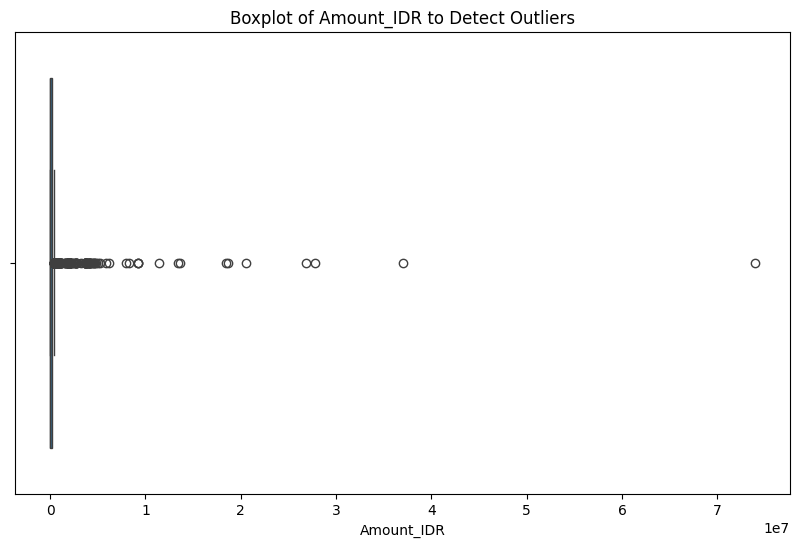

In [15]:
# Pengecekan outlier
# Hitung IQR untuk kolom 'Amount_IDR'
Q1 = df_daily['Amount_IDR'].quantile(0.25)
Q3 = df_daily['Amount_IDR'].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas atas dan batas bawah untuk outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifikasi outlier
outliers = df_daily[(df_daily['Amount_IDR'] < lower_bound) | (df_daily['Amount_IDR'] > upper_bound)]

print(f"Q1 (Kuartil Pertama): {Q1:,.2f}")
print(f"Q3 (Kuartil Ketiga): {Q3:,.2f}")
print(f"IQR (Rentang Antarkuartil): {IQR:,.2f}")
print(f"Batas Bawah Outlier: {lower_bound:,.2f}")
print(f"Batas Atas Outlier: {upper_bound:,.2f}")

print(f"\nJumlah Outlier yang terdeteksi: {len(outliers)}")
print("Outlier (5 baris pertama):")
display(outliers.head())

# Visualisasi outlier menggunakan boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_daily['Amount_IDR'])
plt.title('Boxplot of Amount_IDR to Detect Outliers')
plt.xlabel('Amount_IDR')
plt.show()

Outlier pada kolom 'Amount_IDR' telah ditangani dengan capping.


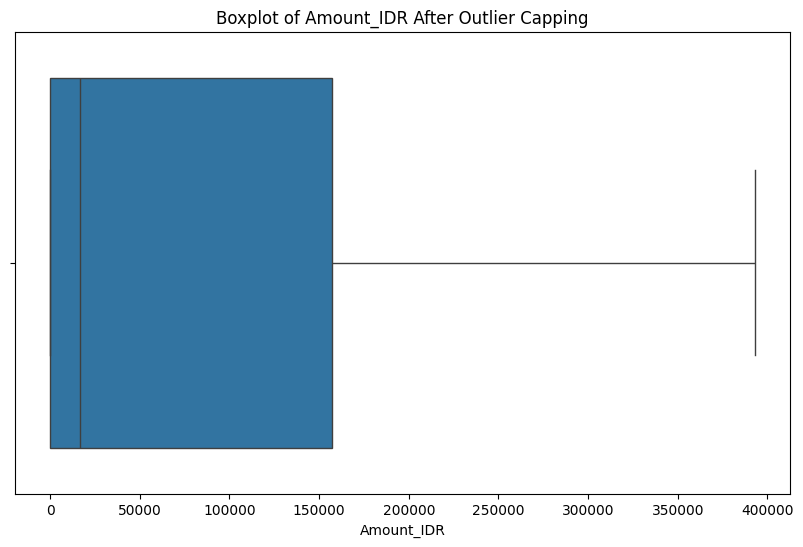

In [16]:
# Terapkan capping untuk outlier pada kolom 'Amount_IDR'
df_daily['Amount_IDR'] = np.where(df_daily['Amount_IDR'] < lower_bound,
                                          lower_bound,
                                          np.where(df_daily['Amount_IDR'] > upper_bound,
                                                     upper_bound,
                                                     df_daily['Amount_IDR']))

print("Outlier pada kolom 'Amount_IDR' telah ditangani dengan capping.")

# Verifikasi perubahan dengan boxplot lagi
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_daily['Amount_IDR'])
plt.title('Boxplot of Amount_IDR After Outlier Capping')
plt.xlabel('Amount_IDR')
plt.show()

In [17]:
# Cek bentuk pemusatan dengan mean, median, modus
mean_amount_idr = df_daily['Amount_IDR'].mean()
median_amount_idr = df_daily['Amount_IDR'].median()
mode_amount_idr = df_daily['Amount_IDR'].mode()

print(f"Mean Amount_IDR: {mean_amount_idr:,.2f}")
print(f"Median Amount_IDR: {median_amount_idr:,.2f}")
print(f"Modus Amount_IDR: {mode_amount_idr.to_list()}")

Mean Amount_IDR: 99,954.75
Median Amount_IDR: 16,560.00
Modus Amount_IDR: [0.0]


In [18]:
# Perbandingan dataset sebelum dan sesudah capping
# Untuk perbandingan, mari kita ambil lagi data sebelum capping, dengan struktur yang sama seperti df_daily sebelum capping.

# Asumsi 'df' di sini adalah DataFrame setelah category mapping dan drop kolom 'Subcategory', 'Note'
# dan 'Date' telah diubah ke datetime objects (dari step sebelumnya)

# 1. PERBAIKAN: Gunakan format='mixed' untuk menangani data yang punya jam dan yang tidak
df['Date_Datetime'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

# Lakukan normalisasi ke tingkat hari (membuang elemen jam/menit jika ada)
df['Date_Only'] = df['Date_Datetime'].dt.normalize()

# 2. Membuat Pivot Table (untuk df_before_capping)
df_before_capping = df.pivot_table(
    index='Date_Only',
    columns='Standard_Category',
    values='Amount',
    aggfunc='sum',
    fill_value=0
)

# 3. Tambahkan fitur Total Pengeluaran Harian
expense_columns_before_capping = [col for col in df_before_capping.columns if col != 'Income']
df_before_capping['Total_Daily_Expense'] = df_before_capping[expense_columns_before_capping].sum(axis=1)

# 4. Rapikan tabel
df_before_capping = df_before_capping.reset_index().rename(columns={'Date_Only': 'Date'})

# 5. Isi tanggal yang hilang agar lengkap dari 2015-01-01 hingga 2018-12-31
start_date_comp = pd.to_datetime('2015-01-01')
end_date_comp = pd.to_datetime('2018-12-31')
full_date_range_comp = pd.date_range(start=start_date_comp, end=end_date_comp, freq='D')

df_before_capping = df_before_capping.set_index('Date')
df_before_capping = df_before_capping.reindex(full_date_range_comp, fill_value=0)
df_before_capping = df_before_capping.reset_index().rename(columns={'index': 'Date'})

# 6. Konversi INR to IDR untuk Amount_IDR
df_before_capping['Amount_IDR'] = df_before_capping['Total_Daily_Expense'] * conversion_rate_inr_to_idr

print("DataFrame 'df_before_capping' (daily aggregated, sebelum capping) telah dibuat ulang.")

DataFrame 'df_before_capping' (daily aggregated, sebelum capping) telah dibuat ulang.


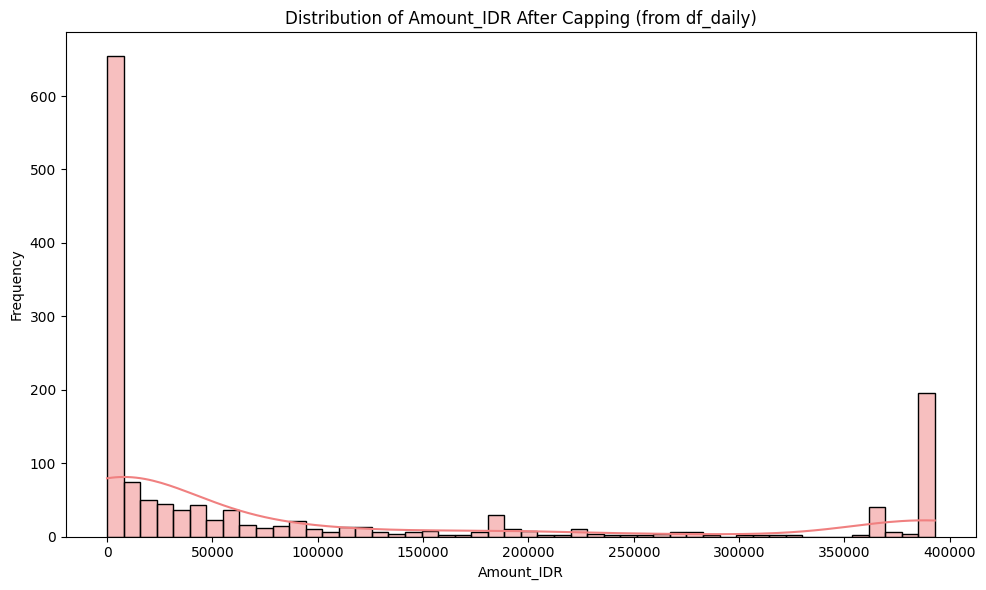

In [19]:
# Menampilkan distribusi 'Amount_IDR' setelah capping menggunakan df_daily

plt.figure(figsize=(10, 6))

sns.histplot(df_daily['Amount_IDR'], kde=True, bins=50, color='lightcoral')
plt.title('Distribution of Amount_IDR After Capping (from df_daily)')
plt.xlabel('Amount_IDR')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

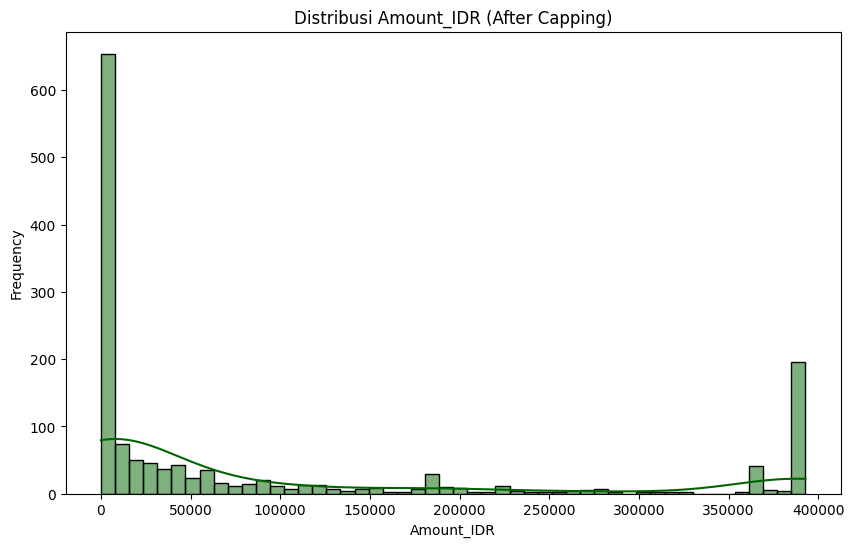

In [20]:
# Histogram melihat dataset normalitas
plt.figure(figsize=(10, 6))
sns.histplot(df_daily['Amount_IDR'], kde=True, bins=50, color='darkgreen')
plt.title('Distribusi Amount_IDR (After Capping)')
plt.xlabel('Amount_IDR')
plt.ylabel('Frequency')
plt.show()

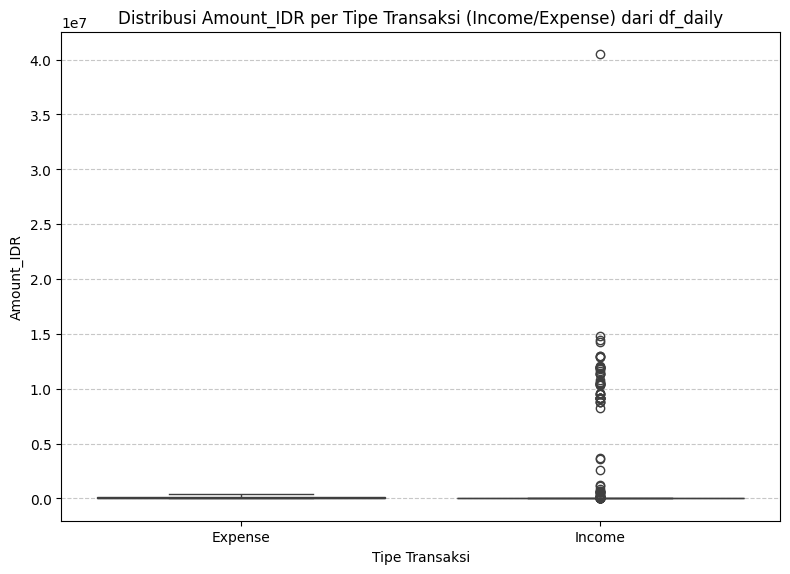

In [21]:
# Boxplot untuk melihat hubungan amount_idr dan tipe transaksi
# Menggunakan df_daily dan membuat struktur yang sesuai untuk plot Income/Expense

# DataFrame untuk daily expenses dari df_daily
df_expenses_plot = df_daily[['Date', 'Amount_IDR']].copy()
df_expenses_plot['Type'] = 'Expense'
df_expenses_plot = df_expenses_plot.rename(columns={'Amount_IDR': 'Value_IDR'})

# DataFrame untuk daily income dari df_daily (dikonversi ke IDR)
df_income_plot = df_daily[['Date', 'Income']].copy()
df_income_plot['Value_IDR'] = df_income_plot['Income'] * conversion_rate_inr_to_idr
df_income_plot['Type'] = 'Income'
df_income_plot = df_income_plot.drop(columns=['Income'])

# Gabungkan kedua DataFrame
df_combined_daily = pd.concat([df_expenses_plot, df_income_plot])

plt.figure(figsize=(8, 6))
sns.boxplot(x='Type', y='Value_IDR', data=df_combined_daily)
plt.title('Distribusi Amount_IDR per Tipe Transaksi (Income/Expense) dari df_daily')
plt.xlabel('Tipe Transaksi')
plt.ylabel('Amount_IDR')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

10 Tanggal dengan Pengeluaran Terbesar:


Standard_Category,Date,Amount_IDR
1351,2018-09-13,392840.0
1339,2018-09-01,392840.0
1331,2018-08-24,392840.0
1330,2018-08-23,392840.0
1329,2018-08-22,392840.0
1320,2018-08-13,392840.0
1312,2018-08-05,392840.0
1308,2018-08-01,392840.0
1307,2018-07-31,392840.0
1304,2018-07-28,392840.0


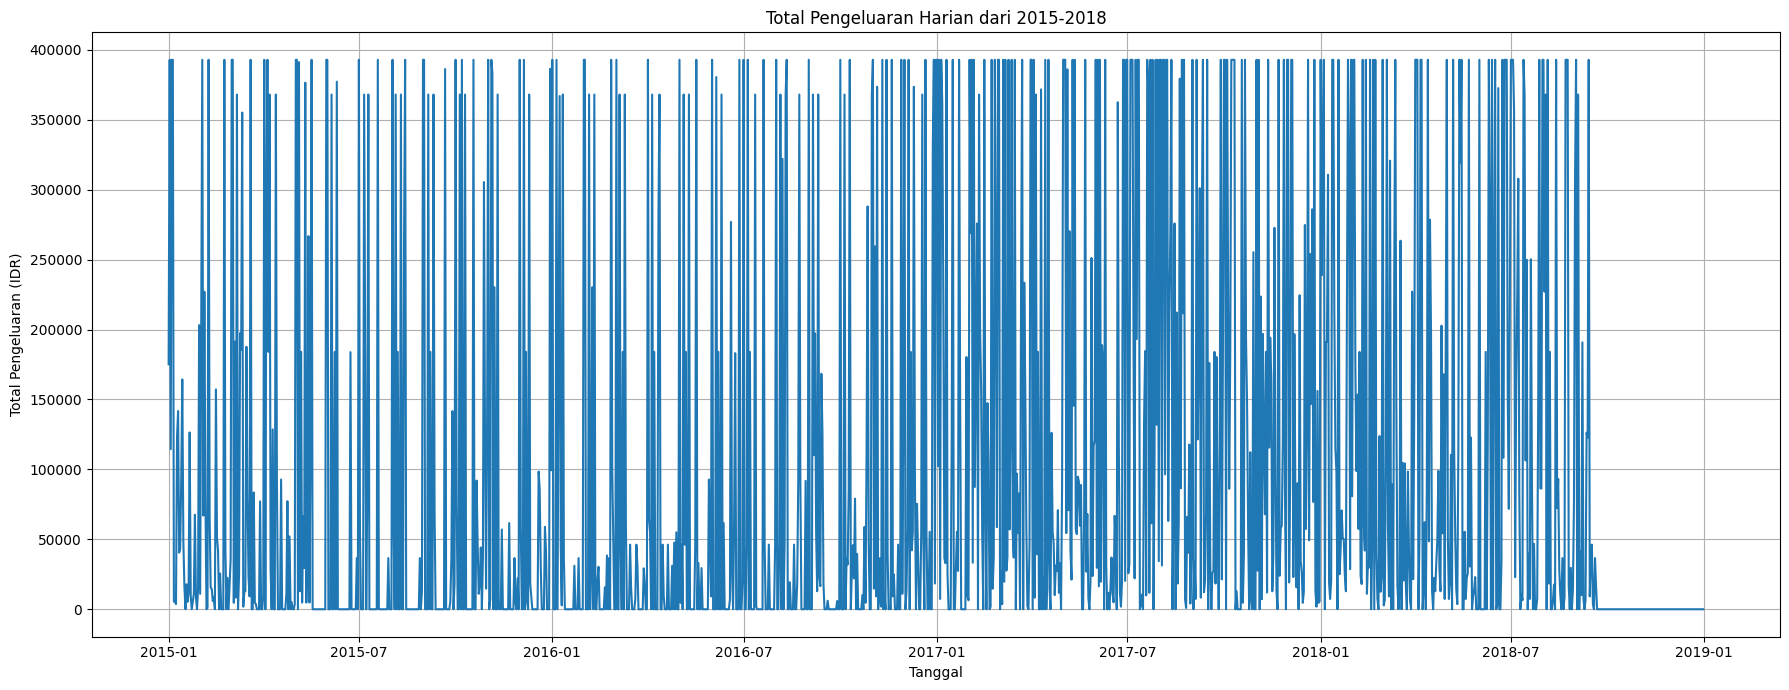

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_daily already contains the daily aggregated expenses with 'Amount_IDR' (capped and in IDR)
# So, we can directly use df_daily for 'daily_expenses'
daily_expenses = df_daily[['Date', 'Amount_IDR']].copy()

# Urutkan daily expense dari yang paling besar
top_expense_dates = daily_expenses.sort_values(by='Amount_IDR', ascending=False).head(10)

print("10 Tanggal dengan Pengeluaran Terbesar:")
display(top_expense_dates)

# Visualisasi total pengeluaran harian
plt.figure(figsize=(18, 7))
sns.lineplot(x='Date', y='Amount_IDR', data=daily_expenses)
plt.title('Total Pengeluaran Harian dari 2015-2018')
plt.xlabel('Tanggal')
plt.ylabel('Total Pengeluaran (IDR)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
df_daily.head()

Standard_Category,Date,Education,Entertainment,Food & Dining,Gifts & Donations,Health & Fitness,Housing,Income,Personal Care,Savings & Investments,Transportation,Utilities,Total_Daily_Expense,Amount_IDR
0,2015-01-01,0.0,40.0,610.0,0.0,0.0,0.0,0.0,0.0,0.0,302.0,0.0,952.0,175168.0
1,2015-01-02,0.0,0.0,104.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10104.0,392840.0
2,2015-01-03,223.0,0.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,622.0,114448.0
3,2015-01-04,0.0,0.0,230.0,0.0,0.0,10000.0,0.0,0.0,0.0,0.0,0.0,10230.0,392840.0
4,2015-01-05,0.0,0.0,135.0,0.0,0.0,5416.0,0.0,0.0,0.0,0.0,0.0,5551.0,392840.0


## Menjawab Pertanyaan Bisnis

1. Berapa besar persentase kenaikan rata-rata pengeluaran harian (Amount_IDR) pada akhir pekan (is_weekend) dibandingkan hari kerja selama 3 bulan terakhir, dan apakah anomali ini menyebabkan pelampauan target anggaran harian lebih dari 5 kali dalam sebulan?

In [33]:
import pandas as pd

# 1. Tentukan 3 bulan terakhir dengan data transaksi yang valid
# Kita akan menggunakan df_daily yang sudah diolah dan capped.
# Cari tanggal terakhir dengan Amount_IDR > 0
last_valid_date = df_daily[df_daily['Amount_IDR'] > 0]['Date'].max()

# Jika tidak ada transaksi sama sekali, atau last_valid_date tidak ditemukan
if pd.isna(last_valid_date):
    print("Tidak ada data transaksi (Amount_IDR > 0) yang ditemukan.")
else:
    print(f"Tanggal transaksi terakhir yang valid: {last_valid_date.strftime('%Y-%m-%d')}")

    # Tentukan rentang 3 bulan terakhir dari last_valid_date
    end_date_period = last_valid_date
    start_date_period = end_date_period - pd.DateOffset(months=3) + pd.DateOffset(days=1)

    # Filter df_daily untuk 3 bulan terakhir
    df_last_3_months = df_daily[(df_daily['Date'] >= start_date_period) & (df_daily['Date'] <= end_date_period)].copy()

    if df_last_3_months.empty:
        print(f"Tidak ada data dalam rentang {start_date_period.strftime('%Y-%m-%d')} hingga {end_date_period.strftime('%Y-%m-%d')}.")
    else:
        print(f"Menganalisis data dari {start_date_period.strftime('%Y-%m-%d')} hingga {end_date_period.strftime('%Y-%m-%d')}.")

        # 2. Hitung rata-rata pengeluaran harian untuk hari kerja dan akhir pekan
        avg_weekday_expense = df_last_3_months[df_last_3_months['is_weekend'] == 0]['Amount_IDR'].mean()
        avg_weekend_expense = df_last_3_months[df_last_3_months['is_weekend'] == 1]['Amount_IDR'].mean()

        print(f"\nRata-rata pengeluaran hari kerja: Rp {avg_weekday_expense:,.2f}")
        print(f"Rata-rata pengeluaran akhir pekan: Rp {avg_weekend_expense:,.2f}")

        # 3. Hitung persentase kenaikan rata-rata pengeluaran akhir pekan dibandingkan hari kerja
        if avg_weekday_expense > 0:
            percentage_increase = ((avg_weekend_expense - avg_weekday_expense) / avg_weekday_expense) * 100
            print(f"Persentase kenaikan rata-rata pengeluaran akhir pekan: {percentage_increase:,.2f}%")
        else:
            print("Tidak dapat menghitung persentase kenaikan karena rata-rata pengeluaran hari kerja adalah nol.")

        # 4. Analisis pelampauan target anggaran harian
        # Asumsi: target anggaran harian adalah rata-rata pengeluaran harian secara keseluruhan untuk setiap bulan
        print("\nAnalisis Pelampauan Target Anggaran Harian pada Akhir Pekan:")

        # Kelompokkan data per bulan
        df_last_3_months['Month_Year'] = df_last_3_months['Date'].dt.to_period('M')

        for month_year, month_data in df_last_3_months.groupby('Month_Year'):
            # Target anggaran harian untuk bulan ini adalah rata-rata pengeluaran harian di bulan ini
            daily_budget_target = month_data['Amount_IDR'].mean()

            # Filter hanya untuk akhir pekan di bulan ini
            weekend_expenses_this_month = month_data[month_data['is_weekend'] == 1]

            if daily_budget_target > 0:
                # Hitung berapa kali pengeluaran akhir pekan melebihi target anggaran harian
                over_budget_count = (weekend_expenses_this_month['Amount_IDR'] > daily_budget_target).sum()

                print(f"- Bulan {month_year.strftime('%B %Y')}:")
                print(f"  Target anggaran harian (rata-rata bulanan): Rp {daily_budget_target:,.2f}")
                print(f"  Jumlah hari akhir pekan melebihi target: {over_budget_count} kali")

                if over_budget_count > 5:
                    print(f"  >>> ANOMALI: Pelampauan target anggaran harian terjadi lebih dari 5 kali ({over_budget_count} kali) pada akhir pekan di bulan ini.")
                else:
                    print(f"  Tidak ada anomali serius: Pelampauan target anggaran harian pada akhir pekan kurang dari atau sama dengan 5 kali.")
            else:
                print(f"- Bulan {month_year.strftime('%B %Y')}: Tidak ada pengeluaran di bulan ini, tidak dapat menentukan target anggaran.")

Tanggal transaksi terakhir yang valid: 2018-09-20
Menganalisis data dari 2018-06-21 hingga 2018-09-20.

Rata-rata pengeluaran hari kerja: Rp 139,621.63
Rata-rata pengeluaran akhir pekan: Rp 139,930.23
Persentase kenaikan rata-rata pengeluaran akhir pekan: 0.22%

Analisis Pelampauan Target Anggaran Harian pada Akhir Pekan:
- Bulan June 2018:
  Target anggaran harian (rata-rata bulanan): Rp 215,603.29
  Jumlah hari akhir pekan melebihi target: 2 kali
  Tidak ada anomali serius: Pelampauan target anggaran harian pada akhir pekan kurang dari atau sama dengan 5 kali.
- Bulan July 2018:
  Target anggaran harian (rata-rata bulanan): Rp 161,813.16
  Jumlah hari akhir pekan melebihi target: 5 kali
  Tidak ada anomali serius: Pelampauan target anggaran harian pada akhir pekan kurang dari atau sama dengan 5 kali.
- Bulan August 2018:
  Target anggaran harian (rata-rata bulanan): Rp 124,941.05
  Jumlah hari akhir pekan melebihi target: 1 kali
  Tidak ada anomali serius: Pelampauan target anggaran 

### Kesimpulan Pertanyaan 1

Meskipun ada sedikit kenaikan pengeluaran pada akhir pekan (0,22%), tidak ada anomali serius yang terdeteksi di mana pengeluaran akhir pekan melampaui target anggaran harian lebih dari 5 kali dalam sebulan selama periode 3 bulan terakhir.

2. Seberapa besar deviasi pengeluaran harian (Amount_IDR) terhadap tren mingguan (Amount_IDR_lag_7) pada periode 'High-Spending' (tanggal 25 hingga tanggal 5 bulan berikutnya) di sepanjang tahun 2015-2018, dan apakah lonjakan tersebut mengonsumsi lebih dari 40% total Income bulanan?

In [34]:
import pandas as pd

# 1. Definisikan periode 'High-Spending' (tanggal 25 hingga tanggal 5 bulan berikutnya)
# Asumsi: df_daily sudah memiliki kolom 'day_of_month', 'month', 'Year' dari proses feature engineering sebelumnya

def is_high_spending_period(day):
    return (day >= 25) or (day <= 5)

df_daily['is_high_spending_period'] = df_daily['day_of_month'].apply(is_high_spending_period)

# 2. Hitung deviasi pengeluaran harian terhadap tren mingguan
# Kita hanya tertarik pada deviasi positif (lonjakan), jadi gunakan max(0, deviasi)
df_daily['deviation_from_weekly_trend'] = (df_daily['Amount_IDR'] - df_daily['Amount_IDR_lag_7']).apply(lambda x: max(0, x))

# Filter data untuk periode 'High-Spending'
df_high_spending = df_daily[df_daily['is_high_spending_period']].copy()

print("Contoh data df_daily dengan kolom 'is_high_spending_period' dan 'deviation_from_weekly_trend':")
display(df_daily[['Date', 'day_of_month', 'is_high_spending_period', 'Amount_IDR', 'Amount_IDR_lag_7', 'deviation_from_weekly_trend']].head(10))

# Agregasi deviasi rata-rata pada periode 'High-Spending'
avg_high_spending_deviation = df_high_spending['deviation_from_weekly_trend'].mean()
print(f"\nRata-rata deviasi pengeluaran harian terhadap tren mingguan pada periode 'High-Spending': Rp {avg_high_spending_deviation:,.2f}")

# 3. Analisis apakah lonjakan tersebut mengonsumsi lebih dari 40% total Income bulanan
# Gabungkan dengan df_monthly_summary untuk mendapatkan total Income bulanan

# Tambahkan kolom Year dan Month ke df_high_spending jika belum ada
df_high_spending['Year'] = df_high_spending['Date'].dt.year
df_high_spending['Month'] = df_high_spending['Date'].dt.month

# Hitung total pengeluaran pada periode high-spending per bulan
monthly_high_spending_sum = df_high_spending.groupby(['Year', 'Month'])['Amount_IDR'].sum().reset_index()
monthly_high_spending_sum = monthly_high_spending_sum.rename(columns={'Amount_IDR': 'High_Spending_Expense_IDR_Monthly'})

# Gabungkan dengan df_monthly_summary (yang sudah berisi 'Income' bulanan)
monthly_analysis = pd.merge(df_monthly_summary[['Year', 'Month', 'Income']],
                          monthly_high_spending_sum,
                          on=['Year', 'Month'],
                          how='left')

# Isi NaN dengan 0 jika tidak ada high spending expense di bulan tersebut
monthly_analysis['High_Spending_Expense_IDR_Monthly'] = monthly_analysis['High_Spending_Expense_IDR_Monthly'].fillna(0)

# Hitung persentase high spending expense terhadap income bulanan
monthly_analysis['High_Spending_Percent_of_Income'] = (
    monthly_analysis['High_Spending_Expense_IDR_Monthly'] / monthly_analysis['Income']
) * 100

# Handle kasus Income = 0 agar tidak terjadi pembagian dengan nol
monthly_analysis.loc[monthly_analysis['Income'] == 0, 'High_Spending_Percent_of_Income'] = 0

print("\nAnalisis Pengeluaran Periode 'High-Spending' vs. Income Bulanan:")
display(monthly_analysis.head())

# Identifikasi bulan-bulan di mana High_Spending_Percent_of_Income > 40%
months_over_40_percent = monthly_analysis[monthly_analysis['High_Spending_Percent_of_Income'] > 40]

print("\nBulan-bulan di mana pengeluaran 'High-Spending' melebihi 40% dari total Income:")
if not months_over_40_percent.empty:
    display(months_over_40_percent)
    print(f"Total ada {len(months_over_40_percent)} bulan dengan pengeluaran 'High-Spending' di atas 40% dari income.")
else:
    print("Tidak ada bulan di mana pengeluaran 'High-Spending' melebihi 40% dari total Income.")

Contoh data df_daily dengan kolom 'is_high_spending_period' dan 'deviation_from_weekly_trend':


Standard_Category,Date,day_of_month,is_high_spending_period,Amount_IDR,Amount_IDR_lag_7,deviation_from_weekly_trend
0,2015-01-01,1,True,175168.0,0.0,175168.0
1,2015-01-02,2,True,392840.0,0.0,392840.0
2,2015-01-03,3,True,114448.0,0.0,114448.0
3,2015-01-04,4,True,392840.0,0.0,392840.0
4,2015-01-05,5,True,392840.0,0.0,392840.0
5,2015-01-06,6,False,5520.0,0.0,5520.0
6,2015-01-07,7,False,5704.0,0.0,5704.0
7,2015-01-08,8,False,3680.0,175168.0,0.0
8,2015-01-09,9,False,123280.0,392840.0,0.0
9,2015-01-10,10,False,141680.0,114448.0,27232.0



Rata-rata deviasi pengeluaran harian terhadap tren mingguan pada periode 'High-Spending': Rp 90,573.84

Analisis Pengeluaran Periode 'High-Spending' vs. Income Bulanan:


,Year,Month,Income,High_Spending_Expense_IDR_Monthly,High_Spending_Percent_of_Income
0,2015,1,0.0,1783696.0,0.000000
1,2015,2,49806.0,1002800.0,2013.412039
2,2015,3,70806.0,1098112.0,1550.874220
3,2015,4,49306.0,1132888.0,2297.667627
4,2015,5,47859.0,1573384.0,3287.540484



Bulan-bulan di mana pengeluaran 'High-Spending' melebihi 40% dari total Income:


,Year,Month,Income,High_Spending_Expense_IDR_Monthly,High_Spending_Percent_of_Income
1,2015,2,49806.00,1002800.00,2013.412039
2,2015,3,70806.00,1098112.00,1550.874220
3,2015,4,49306.00,1132888.00,2297.667627
4,2015,5,47859.00,1573384.00,3287.540484
5,2015,6,47859.00,797456.00,1666.261309
6,2015,7,47859.00,486864.00,1017.288284
7,2015,8,49806.00,1264816.00,2539.485203
8,2015,9,54606.00,963056.00,1763.645021
9,2015,10,49806.00,1495920.00,3003.493555
10,2015,11,51306.00,1239792.00,2416.465910


Total ada 44 bulan dengan pengeluaran 'High-Spending' di atas 40% dari income.


### Kesimpulan Pertanyaan 2

Terdapat lonjakan pengeluaran yang signifikan pada periode 'High-Spending' dengan rata-rata deviasi harian sekitar Rp 90.573,84. Lonjakan ini menyebabkan pengeluaran periode 'High-Spending' melampaui 40% dari total pendapatan bulanan secara konsisten dan drastis untuk banyak bulan sepanjang tahun 2015-2018. Hal ini mengindikasikan adanya ketidakseimbangan yang besar antara pengeluaran di periode krusial ini dengan kemampuan pendapatan bulanan untuk menutupinya, terutama jika pendapatan aktual lebih tinggi dari yang tercatat atau terdapat sumber pendapatan lain yang tidak masuk dalam perhitungan.

## Data Splitting Monthly

Ringkasan Income dan Expense Bulanan dari Januari 2015 hingga Desember 2018:


Standard_Category,Year,Month,Income,Expense_IDR
0,2015,1,0.0,2647760.0
1,2015,2,49806.0,2220144.0
2,2015,3,70806.0,3048033.6
3,2015,4,49306.0,2482528.0
4,2015,5,47859.0,3087704.0


Standard_Category,Year,Month,Income,Expense_IDR
43,2018,8,71735.75,3873172.4
44,2018,9,3500.00,1807800.0
45,2018,10,0.00,0.0
46,2018,11,0.00,0.0
47,2018,12,0.00,0.0


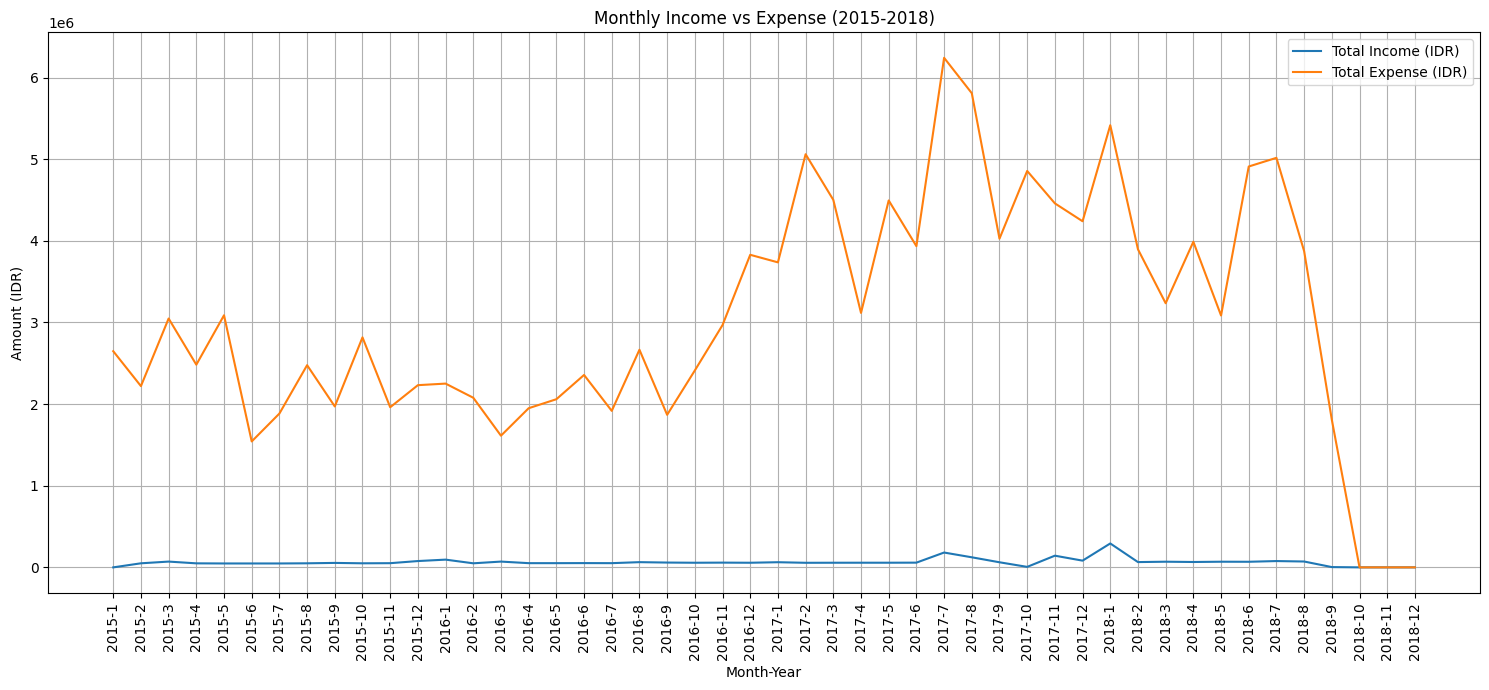

In [24]:
# Ekstrak tahun dan bulan dari kolom 'Date'
df_daily['Year'] = df_daily['Date'].dt.year
df_daily['Month'] = df_daily['Date'].dt.month

# Filter data untuk rentang tahun 2015-2018
df_filtered_monthly = df_daily[(df_daily['Year'] >= 2015) & (df_daily['Year'] <= 2018)]

# Hitung total income dan expense bulanan
df_monthly_summary = df_filtered_monthly.groupby(['Year', 'Month']).agg({
    'Income': 'sum',
    'Amount_IDR': 'sum'
}).reset_index()

# Ganti nama kolom Amount_IDR menjadi Expense_IDR untuk kejelasan
df_monthly_summary = df_monthly_summary.rename(columns={'Amount_IDR': 'Expense_IDR'})

# Urutkan berdasarkan tahun dan bulan
df_monthly_summary = df_monthly_summary.sort_values(by=['Year', 'Month'])

print("Ringkasan Income dan Expense Bulanan dari Januari 2015 hingga Desember 2018:")
display(df_monthly_summary.head())
display(df_monthly_summary.tail())

# Opsional: Visualisasi
plt.figure(figsize=(15, 7))
plt.plot(df_monthly_summary['Year'].astype(str) + '-' + df_monthly_summary['Month'].astype(str),
         df_monthly_summary['Income'], label='Total Income (IDR)')
plt.plot(df_monthly_summary['Year'].astype(str) + '-' + df_monthly_summary['Month'].astype(str),
         df_monthly_summary['Expense_IDR'], label='Total Expense (IDR)')

plt.title('Monthly Income vs Expense (2015-2018)')
plt.xlabel('Month-Year')
plt.ylabel('Amount (IDR)')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Hitung selisih (balance) antara Income dan Expense_IDR
df_monthly_summary['Balance'] = df_monthly_summary['Income'] - df_monthly_summary['Expense_IDR']

# Inisialisasi list untuk menyimpan bulan yang tidak balance
unbalanced_months = []

# Cek setiap bulan
for index, row in df_monthly_summary.iterrows():
    year = int(row['Year'])
    month = int(row['Month'])
    balance = row['Balance']

    # Jika balance tidak nol (dengan toleransi kecil untuk floating point)
    if abs(balance) > 0.01: # Menggunakan toleransi kecil untuk komparasi float
        month_name = pd.to_datetime(f'{year}-{month}-01').strftime('%B %Y')
        if balance < 0:
            unbalanced_months.append(f"Bulan {month_name}: Kekurangan uang sebesar Rp {abs(balance):,.2f}")
        else:
            unbalanced_months.append(f"Bulan {month_name}: Kelebihan uang sebesar Rp {balance:,.2f}")

# Cetak hasil
if not unbalanced_months:
    print("OK: Setiap bulan dari Januari 2015 hingga Desember 2018, income dan expensenya balance.")
else:
    print("TIDAK OK: Terdapat bulan-bulan yang tidak balance antara income dan expensenya:")
    for entry in unbalanced_months:
        print(f"- {entry}")

# Tampilkan ringkasan bulanan dengan kolom Balance (opsional)
print("\nRingkasan bulanan dengan kolom Balance:")
display(df_monthly_summary[['Year', 'Month', 'Income', 'Expense_IDR', 'Balance']].head())
display(df_monthly_summary[['Year', 'Month', 'Income', 'Expense_IDR', 'Balance']].tail())

TIDAK OK: Terdapat bulan-bulan yang tidak balance antara income dan expensenya:
- Bulan January 2015: Kekurangan uang sebesar Rp 2,647,760.00
- Bulan February 2015: Kekurangan uang sebesar Rp 2,170,338.00
- Bulan March 2015: Kekurangan uang sebesar Rp 2,977,227.60
- Bulan April 2015: Kekurangan uang sebesar Rp 2,433,222.00
- Bulan May 2015: Kekurangan uang sebesar Rp 3,039,845.00
- Bulan June 2015: Kekurangan uang sebesar Rp 1,494,613.00
- Bulan July 2015: Kekurangan uang sebesar Rp 1,836,301.00
- Bulan August 2015: Kekurangan uang sebesar Rp 2,426,650.00
- Bulan September 2015: Kekurangan uang sebesar Rp 1,916,402.00
- Bulan October 2015: Kekurangan uang sebesar Rp 2,767,418.00
- Bulan November 2015: Kekurangan uang sebesar Rp 1,909,950.00
- Bulan December 2015: Kekurangan uang sebesar Rp 2,154,401.00
- Bulan January 2016: Kekurangan uang sebesar Rp 2,156,066.00
- Bulan February 2016: Kekurangan uang sebesar Rp 2,027,738.00
- Bulan March 2016: Kekurangan uang sebesar Rp 1,542,138.00
-

Standard_Category,Year,Month,Income,Expense_IDR,Balance
0,2015,1,0.0,2647760.0,-2647760.0
1,2015,2,49806.0,2220144.0,-2170338.0
2,2015,3,70806.0,3048033.6,-2977227.6
3,2015,4,49306.0,2482528.0,-2433222.0
4,2015,5,47859.0,3087704.0,-3039845.0


Standard_Category,Year,Month,Income,Expense_IDR,Balance
43,2018,8,71735.75,3873172.4,-3801436.65
44,2018,9,3500.00,1807800.0,-1804300.00
45,2018,10,0.00,0.0,0.00
46,2018,11,0.00,0.0,0.00
47,2018,12,0.00,0.0,0.00


In [26]:
# Pastikan df_monthly_summary sudah diurutkan berdasarkan waktu (Year dan Month)
df_monthly_summary = df_monthly_summary.sort_values(by=['Year', 'Month']).reset_index(drop=True)

# Tentukan ukuran dataset training (80%) dan testing (20%)
train_size_monthly = int(len(df_monthly_summary) * 0.8)

# Bagi dataset menjadi training dan testing berdasarkan waktu
df_train_monthly = df_monthly_summary.iloc[:train_size_monthly]
df_test_monthly = df_monthly_summary.iloc[train_size_monthly:]

print(f"Ukuran dataset training bulanan (df_train_monthly): {df_train_monthly.shape}")
print(f"Ukuran dataset testing bulanan (df_test_monthly): {df_test_monthly.shape}")

print("\n5 baris pertama df_train_monthly:")
display(df_train_monthly.head())

print("\n5 baris pertama df_test_monthly:")
display(df_test_monthly.head())

Ukuran dataset training bulanan (df_train_monthly): (38, 5)
Ukuran dataset testing bulanan (df_test_monthly): (10, 5)

5 baris pertama df_train_monthly:


Standard_Category,Year,Month,Income,Expense_IDR,Balance
0,2015,1,0.0,2647760.0,-2647760.0
1,2015,2,49806.0,2220144.0,-2170338.0
2,2015,3,70806.0,3048033.6,-2977227.6
3,2015,4,49306.0,2482528.0,-2433222.0
4,2015,5,47859.0,3087704.0,-3039845.0



5 baris pertama df_test_monthly:


Standard_Category,Year,Month,Income,Expense_IDR,Balance
38,2018,3,69343.50,3235203.92,-3165860.42
39,2018,4,65824.15,3988200.00,-3922375.85
40,2018,5,69238.00,3085128.00,-3015890.00
41,2018,6,68551.00,4909887.28,-4841336.28
42,2018,7,77267.50,5016208.00,-4938940.50


In [27]:
df_train_monthly.to_csv('df_train_monthly.csv', index=False)
df_test_monthly.to_csv('df_test_monthly.csv', index=False)

print("Dataset training bulanan (df_train_monthly) dan testing bulanan (df_test_monthly) telah berhasil disimpan ke file CSV masing-masing.")

Dataset training bulanan (df_train_monthly) dan testing bulanan (df_test_monthly) telah berhasil disimpan ke file CSV masing-masing.


## Data Splitting Daily

In [28]:
import numpy as np

# Ganti df_daily dengan df_before_capping yang memiliki semua 1461 tanggal
# df_before_capping sudah diurutkan berdasarkan tanggal dan di-reset index-nya.
df_daily = df_before_capping.copy()

# --- Re-apply Outlier Capping ---
# Hitung ulang IQR untuk kolom 'Amount_IDR' pada df_daily (yang sekarang sama dengan df_before_capping)
Q1_recalc = df_daily['Amount_IDR'].quantile(0.25)
Q3_recalc = df_daily['Amount_IDR'].quantile(0.75)
IQR_recalc = Q3_recalc - Q1_recalc

# Tentukan batas atas dan batas bawah untuk outlier
lower_bound_recalc = Q1_recalc - 1.5 * IQR_recalc
upper_bound_recalc = Q3_recalc + 1.5 * IQR_recalc

# Terapkan capping untuk outlier pada kolom 'Amount_IDR'
df_daily['Amount_IDR'] = np.where(df_daily['Amount_IDR'] < lower_bound_recalc,
                                          lower_bound_recalc,
                                          np.where(df_daily['Amount_IDR'] > upper_bound_recalc,
                                                     upper_bound_recalc,
                                                     df_daily['Amount_IDR']))
print("Outlier pada kolom 'Amount_IDR' telah ditangani dengan capping pada df_daily yang direkonstruksi.")

# --- Re-calculate Feature Engineering Columns ---

# Pastikan df_daily diurutkan berdasarkan tanggal untuk perhitungan balance dan lag yang benar
df_daily = df_daily.sort_values(by='Date').reset_index(drop=True)

df_daily['day_of_week'] = df_daily['Date'].dt.dayofweek
df_daily['month'] = df_daily['Date'].dt.month
df_daily['day_of_month'] = df_daily['Date'].dt.day
df_daily['is_weekend'] = df_daily['day_of_week'].isin([5,6]).astype(int)

# Tambahkan kolom lag untuk 'Amount_IDR'
df_daily['Amount_IDR_lag_1'] = df_daily['Amount_IDR'].shift(1).fillna(0)
df_daily['Amount_IDR_lag_7'] = df_daily['Amount_IDR'].shift(7).fillna(0)

# Menampilkan beberapa baris pertama dan terakhir untuk verifikasi
print("\nDataFrame df_daily setelah rekonstruksi dan capping:")
display(df_daily[['Date', 'Income', 'Amount_IDR', 'Amount_IDR_lag_1', 'Amount_IDR_lag_7', 'day_of_week', 'month', 'day_of_month', 'is_weekend']].head())

print("\nBeberapa baris terakhir:")
display(df_daily[['Date', 'Income', 'Amount_IDR', 'Amount_IDR_lag_1', 'Amount_IDR_lag_7', 'day_of_week', 'month', 'day_of_month', 'is_weekend']].tail())

print("\nJumlah NaN per kolom setelah rekonstruksi:")
display(df_daily.isnull().sum())

Outlier pada kolom 'Amount_IDR' telah ditangani dengan capping pada df_daily yang direkonstruksi.

DataFrame df_daily setelah rekonstruksi dan capping:


Standard_Category,Date,Income,Amount_IDR,Amount_IDR_lag_1,Amount_IDR_lag_7,day_of_week,month,day_of_month,is_weekend
0,2015-01-01,0.0,175168.0,0.0,0.0,3,1,1,0
1,2015-01-02,0.0,392840.0,175168.0,0.0,4,1,2,0
2,2015-01-03,0.0,114448.0,392840.0,0.0,5,1,3,1
3,2015-01-04,0.0,392840.0,114448.0,0.0,6,1,4,1
4,2015-01-05,0.0,392840.0,392840.0,0.0,0,1,5,0



Beberapa baris terakhir:


Standard_Category,Date,Income,Amount_IDR,Amount_IDR_lag_1,Amount_IDR_lag_7,day_of_week,month,day_of_month,is_weekend
1456,2018-12-27,0.0,0.0,0.0,0.0,3,12,27,0
1457,2018-12-28,0.0,0.0,0.0,0.0,4,12,28,0
1458,2018-12-29,0.0,0.0,0.0,0.0,5,12,29,1
1459,2018-12-30,0.0,0.0,0.0,0.0,6,12,30,1
1460,2018-12-31,0.0,0.0,0.0,0.0,0,12,31,0



Jumlah NaN per kolom setelah rekonstruksi:


,0
Standard_Category,
Date,0
Education,0
Entertainment,0
Food & Dining,0
Gifts & Donations,0
Health & Fitness,0
Housing,0
Income,0
Personal Care,0


In [29]:
num_rows_with_income = df_daily[df_daily['Income'] > 0].shape[0]
print(f"Jumlah baris di df_daily yang memiliki nilai Income > 0 adalah: {num_rows_with_income}")

Jumlah baris di df_daily yang memiliki nilai Income > 0 adalah: 108


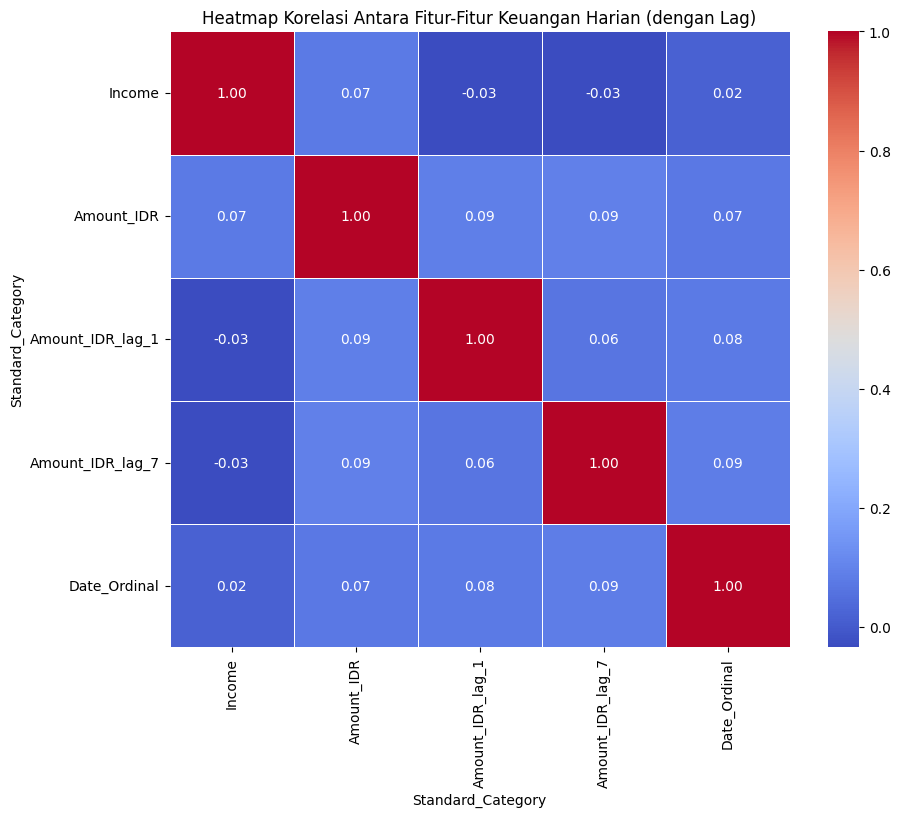

Standard_Category,Date,Income,Amount_IDR,Amount_IDR_lag_1,Amount_IDR_lag_7,day_of_week,month,day_of_month,is_weekend
0,2015-01-01,0.0,175168.0,0.0,0.0,3,1,1,0
1,2015-01-02,0.0,392840.0,175168.0,0.0,4,1,2,0
2,2015-01-03,0.0,114448.0,392840.0,0.0,5,1,3,1
3,2015-01-04,0.0,392840.0,114448.0,0.0,6,1,4,1
4,2015-01-05,0.0,392840.0,392840.0,0.0,0,1,5,0


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih kolom-kolom yang relevan dari df_daily
# Pastikan df_daily memiliki kolom-kolom ini dan 'Date' adalah datetime

# Buat salinan DataFrame untuk menghindari SettingWithCopyWarning
df_for_heatmap = df_daily[['Date', 'Income', 'Amount_IDR', 'Amount_IDR_lag_1', 'Amount_IDR_lag_7']].copy()

# Konversi 'Date' ke format numerik (ordinal) agar bisa dihitung korelasinya
df_for_heatmap['Date_Ordinal'] = df_for_heatmap['Date'].apply(lambda x: x.toordinal())

# Hapus kolom 'Date' asli jika tidak diperlukan untuk korelasi numerik
df_for_heatmap = df_for_heatmap.drop(columns=['Date'])

# Hitung matriks korelasi
correlation_matrix = df_for_heatmap.corr()

# Visualisasikan dengan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antara Fitur-Fitur Keuangan Harian (dengan Lag)')
plt.show()
display(df_daily[['Date', 'Income', 'Amount_IDR', 'Amount_IDR_lag_1', 'Amount_IDR_lag_7', 'day_of_week', 'month', 'day_of_month', 'is_weekend']].head())

In [31]:
import numpy as np

# Pastikan data sudah diurutkan berdasarkan tanggal
# df_daily sudah diurutkan berdasarkan tanggal di step sebelumnya, namun untuk memastikan kita panggil lagi sort_values
df_daily_sorted = df_daily.sort_values(by='Date').reset_index(drop=True)

# Pilih kolom-kolom yang terbaru seperti yang diminta, termasuk fitur waktu yang baru
selected_columns = ['Date', 'Income', 'Amount_IDR', 'Amount_IDR_lag_1', 'Amount_IDR_lag_7','day_of_week', 'month', 'day_of_month', 'is_weekend']
df_daily_filtered = df_daily_sorted[selected_columns]

# Tentukan ukuran dataset training (80%) dan testing (20%)
train_size = int(len(df_daily_filtered) * 0.8)

# Bagi dataset menjadi training dan testing berdasarkan waktu
df_train_daily = df_daily_filtered.iloc[:train_size]
df_test_daily = df_daily_filtered.iloc[train_size:]

print(f"Ukuran dataset training: {df_train_daily.shape}")
print(f"Ukuran dataset testing: {df_test_daily.shape}")

display(df_train_daily.head())
display(df_test_daily.head())

Ukuran dataset training: (1168, 9)
Ukuran dataset testing: (293, 9)


Standard_Category,Date,Income,Amount_IDR,Amount_IDR_lag_1,Amount_IDR_lag_7,day_of_week,month,day_of_month,is_weekend
0,2015-01-01,0.0,175168.0,0.0,0.0,3,1,1,0
1,2015-01-02,0.0,392840.0,175168.0,0.0,4,1,2,0
2,2015-01-03,0.0,114448.0,392840.0,0.0,5,1,3,1
3,2015-01-04,0.0,392840.0,114448.0,0.0,6,1,4,1
4,2015-01-05,0.0,392840.0,392840.0,0.0,0,1,5,0


Standard_Category,Date,Income,Amount_IDR,Amount_IDR_lag_1,Amount_IDR_lag_7,day_of_week,month,day_of_month,is_weekend
1168,2018-03-14,0.0,147361.92,392840.00,9200.0,2,3,14,0
1169,2018-03-15,0.0,17664.00,147361.92,320712.0,3,3,15,0
1170,2018-03-16,0.0,0.00,17664.00,0.0,4,3,16,0
1171,2018-03-17,0.0,12328.00,0.00,89240.0,5,3,17,1
1172,2018-03-18,0.0,263488.00,12328.00,0.0,6,3,18,1


In [32]:
df_train_daily.to_csv('df_train_daily.csv', index=False)
df_test_daily.to_csv('df_test_daily.csv', index=False)

print("Dataset training dan testing telah berhasil disimpan ke 'df_train.csv' dan 'df_test.csv'.")

Dataset training dan testing telah berhasil disimpan ke 'df_train.csv' dan 'df_test.csv'.
